Guided Practice: Implementing DBSCAN Algorithm From Scratch

Welcome to the practice notebook. In this assignment, you will implement the Density-Based Spatial Clustering of Applications with Noise (DBSCAN) algorithm. Unlike K-Means, DBSCAN can find non-convex clusters and robustly handle noise (outliers).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import torch

# Device configuration for future deep learning integrations
device = ('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Configured device: {device}")

Configured device: cpu


Step 1: Generating Synthetic Data

We will generate a 2D dataset featuring interlocking half-moons. Centroid-based algorithms like K-Means fail on this type of spatial structure, making it a perfect use case for demonstrating DBSCAN.

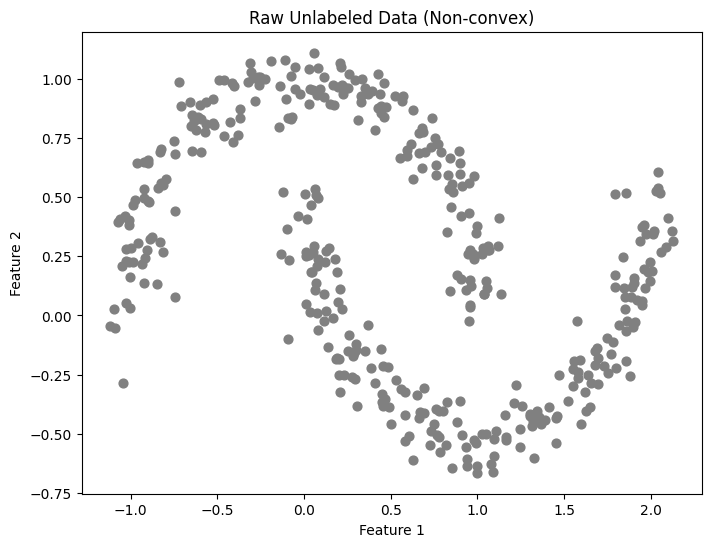

In [2]:
# Generate non-convex data (interlocking moons)
X, y_true = make_moons(n_samples=400, noise=0.08, random_state=42)

# Plot the raw data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=40, color='gray')
plt.title("Raw Unlabeled Data (Non-convex)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Step 2: Region Query

Write a function that finds all points within the epsilon-neighborhood of a given point. This function must calculate the Euclidean distance between the target point and all other points in the dataset.

In [5]:
def region_query(X, point_idx, eps):
    """
    Find all points in the dataset X that are within eps distance of X[point_idx].
    
    Parameters:
    X : array-like of shape (n_samples, n_features)
    point_idx : int, index of the core point candidate
    eps : float, maximum distance (radius) to be considered in the neighborhood
    
    Returns:
    neighbors : list of indices of points within the eps-neighborhood
    """
    # Calculate distances from X[point_idx] to all points in X
    X = np.array(X)
    point = X[point_idx]
    distances = np.linalg.norm(X - point, axis=1)
    neighbors = np.where(distances <= eps)[0]
    # Return a list of indices of points where the distance is <= eps
    print(neighbors.tolist())
    return neighbors.tolist()


Step 3: Expand Cluster

This function is responsible for building a cluster out from a verified core point. It iteratively adds density-reachable points to the cluster. If a new point added to the cluster is also a core point, its neighbors are dynamically added to the search queue.

In [7]:
def expand_cluster(X, labels, point_idx, neighbors, cluster_id, eps, min_pts):
    """
    Expand the cluster to include all density-reachable points.
    
    Parameters:
    X : array-like of shape (n_samples, n_features)
    labels : array-like of shape (n_samples,), cluster assignments (-1 for noise, 0 for unvisited)
    point_idx : int, index of the starting core point
    neighbors : list, indices of points in the eps-neighborhood of the starting point
    cluster_id : int, the current cluster identifier
    eps : float, radius
    min_pts : int, minimum points required to form a core point
    """
    # Assign the starting point to the cluster
    labels[point_idx] = cluster_id
    
    i = 0
    while i < len(neighbors):
        neighbor_idx = neighbors[i]
        
        # If the point was previously marked as noise, it becomes a border point of this cluster
        if labels[neighbor_idx] == -1:
            labels[neighbor_idx] = cluster_id
        
        # If the point is unvisited (label == 0)
        elif labels[neighbor_idx] == 0:
            # Assign to current cluster
            labels[neighbor_idx] = cluster_id
            
            #Find the eps-neighborhood of this newly discovered point using region_query
            neighbor_neighbors = region_query(X, neighbor_idx, eps)
            # If this neighbor is also a core point (has >= min_pts in its neighborhood),
            # append its neighbors to the 'neighbors' list so they can be explored in this loop
            if len(neighbor_neighbors) >= min_pts:
                # Add new neighbors to search list (avoid missing density-reachable points)
                neighbors.extend(neighbor_neighbors)
            pass
            
        i += 1

Step 4: The Main DBSCAN Algorithm

Combine the region query and expand cluster functions to iterate through the entire dataset. Unvisited points are initially labeled as 0. Noise points are labeled as -1. Valid clusters are assigned unique IDs starting from 1.

In [ ]:
def dbscan(X, eps, min_pts):
    """
    Perform DBSCAN clustering.
    
    Parameters:
    X : array-like of shape (n_samples, n_features)
    eps : float, radius of the neighborhood
    min_pts : int, minimum number of points required to define a core point
    
    Returns:
    labels : array of shape (n_samples,) with cluster assignments
    """
    n_samples = X.shape[0]
    # Initialize all labels to 0 (unvisited). We will use -1 for noise.
    labels = np.zeros(n_samples)
    cluster_id = 0
    
    for point_idx in range(n_samples):
        # Skip points that have already been visited
        if labels[point_idx] != 0:
            continue
            
        # Find the epsilon-neighborhood of the current point
        neighbors = region_query(X, point_idx, eps)
        
        #  If the point is not a core point (len(neighbors) < min_pts),
        # label it as noise (-1)
        
        if len(neighbors) < min_pts:
            labels[point_idx] = -1

        # Otherwise, increment cluster_id and call expand_cluster
        else:
            cluster_id += 1
            expand_cluster(X,labels,point_idx,neighbors,cluster_id,eps,min_pts)
        
    return labels

Step 5: Execution and Visualization

Uncomment the block below to run your DBSCAN implementation. We will use eps=0.15 and min_pts=5. The resulting plot will show the distinct continuous clusters in different colors, and the noise outliers in black.

[0, 82, 201, 229, 294, 320, 328, 340]
[0, 82, 229]
[0, 138, 187, 201, 319, 340]
[0, 82, 229, 277, 294, 320, 328, 340]
[0, 229, 277, 294, 320, 328, 340]
[0, 229, 277, 294, 320, 328, 340]
[0, 229, 277, 294, 320, 328, 340]
[0, 161, 201, 229, 277, 294, 319, 320, 328, 340, 390]
[56, 138, 187, 201, 210, 286, 289, 319, 390]
[138, 187, 201, 289, 319]
[3, 56, 138, 161, 187, 201, 203, 210, 236, 268, 286, 289, 315, 319, 331, 340, 390]
[229, 277, 294, 320, 328, 340]
[3, 56, 93, 161, 203, 210, 268, 286, 289, 315, 319, 331, 340, 390]
[3, 56, 93, 138, 161, 203, 210, 236, 268, 286, 289, 315, 319, 331, 340, 390]
[3, 18, 56, 76, 93, 138, 161, 169, 203, 210, 236, 268, 286, 289, 315, 319, 331, 390]
[3, 18, 56, 76, 93, 138, 161, 169, 203, 210, 236, 268, 284, 286, 289, 315, 319, 331, 390]
[3, 56, 93, 138, 161, 169, 203, 210, 236, 268, 286, 289, 315, 319, 331, 390]
[3, 56, 138, 161, 187, 203, 210, 236, 268, 286, 289, 315, 319, 331, 390]
[3, 56, 93, 161, 203, 210, 268, 284, 286, 289, 315, 319, 331, 390]
[3, 5

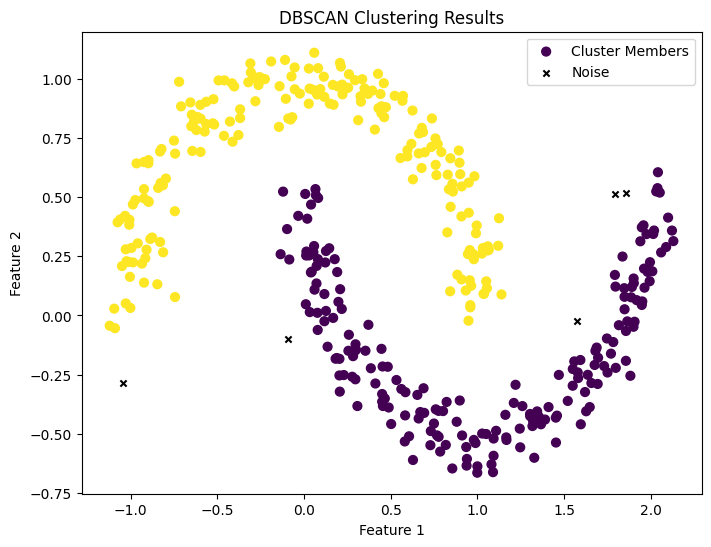

In [9]:
# Parameters
eps = 0.15
min_pts = 5

# Run the implemented algorithm
final_labels = dbscan(X, eps, min_pts)

# Plotting the final results
plt.figure(figsize=(8, 6))

# Create a mask for noise points
noise_mask = (final_labels == -1)
core_and_border_mask = (final_labels != -1)

# Plot core and border points
plt.scatter(X[core_and_border_mask, 0], X[core_and_border_mask, 1], c=final_labels[core_and_border_mask], s=40, cmap='viridis', label='Cluster Members')

# Plot noise points in black
plt.scatter(X[noise_mask, 0], X[noise_mask, 1], c='black', s=20, marker='x', label='Noise')

plt.title("DBSCAN Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()